# CHronoZ Benchmark Modelling
## PCEC96 Delta Distribution Audit

**Normal Benchmark Calibration with Historical Disruption Outlier Isolation**

References: [delta study](analysis.ipynb) and [PPIACO audit](audit-PPIACO.ipynb). This study separates the complete historical record from a statistically filtered calibration reference. No observations are deleted or winsorized.

**Reference timing:** reserve the latest month as a reporting holdout. Fit median/MAD, exclusions, mean/std, and empirical ranges using earlier months only. Freeze that reference when scoring every observation. Historical scores are retrospective, not an expanding-window backtest; source revisions and release timing are not modeled. The cutoff defaults to the penultimate month of the loaded snapshot and is printed below; pin it explicitly to retain the same reference after adding data.

## 1. Load and validate

The real-consumption level has a long-run growth trend. Its raw historical mean is not the Delta Distribution benchmark. Dependencies are in requirements-notebook.txt. Run all cells within the repository.

observations,start,end,missing_values,inferred_frequency
235,2007-01-01,2026-07-01,0,MS


date,level
2007-01-01,"11,181"
2007-02-01,"11,178.2"
2007-03-01,"11,190.7"
2007-04-01,"11,201.5"
2007-05-01,"11,218"


date,level
2026-03-01,"16,730.1"
2026-04-01,"16,763.5"
2026-05-01,"16,825.5"
2026-06-01,"16,900"
2026-07-01,"16,901.3"


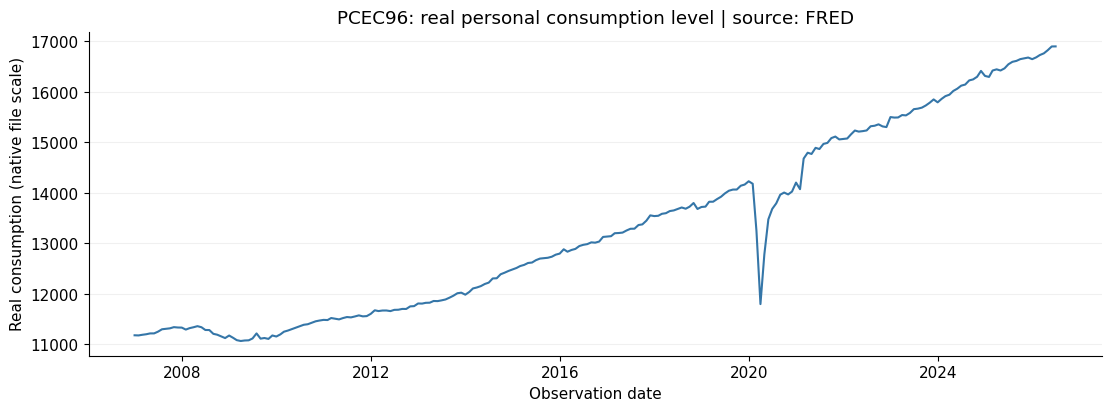

In [1]:
from pathlib import Path
import hashlib,warnings,platform
import numpy as np
import pandas as pd
import scipy,statsmodels,matplotlib
from scipy.stats import gaussian_kde
from statsmodels.tsa.stattools import adfuller,kpss
import matplotlib.pyplot as plt
from IPython.display import display,Markdown,HTML
ROOT=next((p for p in [Path.cwd(),*Path.cwd().parents] if (p/'data/cleaned/PCEC96.csv').is_file()),None)
if ROOT is None:raise FileNotFoundError('Run within the repository.')
def digest(p):return hashlib.sha256(p.read_bytes()).hexdigest()
protected=list((ROOT/'data/cleaned').glob('*.csv'))+[ROOT/'notebook/deltaAnalysis/analysis.ipynb',ROOT/'notebook/deltaAnalysis/audit-PPIACO.ipynb']
hashes={str(p.relative_to(ROOT)):digest(p) for p in protected}
def table(df):display(HTML(df.to_html(index=False,float_format=lambda x:f'{x:,.6g}',escape=True)))
plt.rcParams.update({'font.family':'DejaVu Sans','font.size':11,'figure.facecolor':'white','axes.spines.top':False,'axes.spines.right':False})
raw=pd.read_csv(ROOT/'data/cleaned/PCEC96.csv');assert list(raw)==['date','value']
data=raw.rename(columns={'value':'level'}).copy()
data['date']=pd.to_datetime(data.date,errors='raise');data['level']=pd.to_numeric(data.level,errors='raise')
assert data.date.notna().all() and data.date.is_unique and data.date.is_monotonic_increasing
assert np.isfinite(data.level).all() and data.level.gt(0).all()
meta=pd.read_csv(ROOT/'data/cleaned/series_metadata.csv').set_index('series_id').loc['PCEC96']
assert len(data)==meta.valid_observations and meta.expected_frequency=='monthly'
frequency=pd.infer_freq(data.date);assert frequency=='MS'
consecutive=data.date.dt.to_period('M').astype('int64').diff().eq(1)
assert consecutive.iloc[1:].all(),'Unexpected calendar gaps; do not bridge them.'
table(pd.DataFrame([{'observations':len(data),'start':data.date.min(),'end':data.date.max(),'missing_values':data.isna().sum().sum(),'inferred_frequency':frequency}]))
table(data.head());table(data.tail())
fig,ax=plt.subplots(figsize=(11,4),layout='constrained');ax.plot(data.date,data.level,color='#3576A8')
ax.set(title='PCEC96: real personal consumption level | source: FRED',xlabel='Observation date',ylabel='Real consumption (native file scale)')
ax.grid(axis='y',alpha=.18);plt.show();plt.close(fig)


## 2. Monthly delta

$$\Delta_t=100\ln(PCEC96_t/PCEC96_{t-1}).$$

PCEC96 is positive; relative real-consumption growth is more comparable across changing level scales. This is approximately monthly percent change for small moves, not exact percent for large moves, and is not annualized. The initial row has no delta; all other monthly changes are preserved.

In [2]:
data['previous_level']=data.level.shift()
data['delta_log_pct']=(100*np.log(data.level/data.previous_level)).where(consecutive)
full_delta=data.loc[data.delta_log_pct.notna()].copy()
assert len(full_delta)==len(data)-1
CALIBRATION_END=data.date.iloc[-2]  # Set an explicit date here to pin future reruns.
THRESHOLD=3.5
full_delta['calibration_eligible']=full_delta.date.le(CALIBRATION_END)
calibration_history=full_delta.loc[full_delta.calibration_eligible].copy()
print('Fixed calibration cutoff:',CALIBRATION_END.date(),'| latest reporting month:',data.date.max().date())
table(full_delta.head())


Fixed calibration cutoff: 2026-06-01 | latest reporting month: 2026-07-01


date,level,previous_level,delta_log_pct,calibration_eligible
2007-02-01,"11,178.2","11,181",-0.0250456,True
2007-03-01,"11,190.7","11,178.2",0.111762,True
2007-04-01,"11,201.5","11,190.7",0.0964622,True
2007-05-01,"11,218","11,201.5",0.147193,True
2007-06-01,"11,218.5","11,218",0.00445702,True


## 3. Full historical delta distribution

Statistics include every valid change, including the latest holdout. Standard deviation uses ddof=1; MAD is unscaled median absolute deviation; IQR = P75 - P25. Quantiles use linear interpolation, and skewness/excess kurtosis use bias-corrected sample estimates. KDE uses Scott bandwidth as a visual smoothing guide, not a Gaussian model. Full axes retain all tails.

observations,mean,median,std,MAD,minimum,maximum,P1,P5,P10,P25,P50,P75,P90,P95,P99,skewness,excess_kurtosis,IQR
234,0.17657,0.176642,1.1647,0.163523,-11.5949,7.99397,-0.925235,-0.36699,-0.175,0.0202586,0.176642,0.348908,0.563397,0.776601,3.32633,-3.53464,59.8471,0.328649


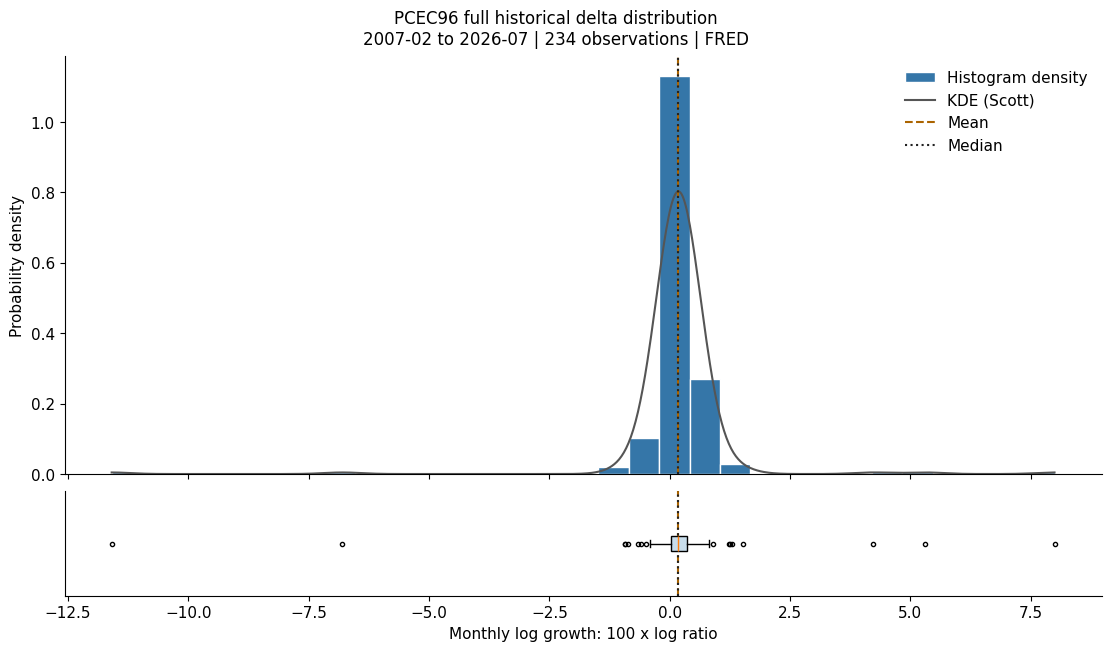

In [3]:
def describe(values):
 s=pd.Series(values).dropna();m=s.median()
 return {'observations':len(s),'mean':s.mean(),'median':m,'std':s.std(ddof=1),'MAD':(s-m).abs().median(),
 'minimum':s.min(),'maximum':s.max(),**{f'P{p}':s.quantile(p/100) for p in [1,5,10,25,50,75,90,95,99]},
 'skewness':s.skew(),'excess_kurtosis':s.kurt(),'IQR':s.quantile(.75)-s.quantile(.25)}
full_stats=describe(full_delta.delta_log_pct)
table(pd.DataFrame([full_stats]))
def distribution_plot(values,title):
 edges=np.histogram_bin_edges(values,bins='auto')
 if len(edges)-1>80:edges=np.linspace(min(values),max(values),81)
 assert np.histogram(values,bins=edges)[0].sum()==len(values)
 fig,(ax,box)=plt.subplots(2,1,figsize=(11,6.4),sharex=True,gridspec_kw={'height_ratios':[4,1]},layout='constrained')
 ax.hist(values,bins=edges,density=True,color='#3576A8',edgecolor='white',label='Histogram density')
 if len(values)>2 and np.std(values)>0:
  grid=np.linspace(min(values),max(values),800);ax.plot(grid,gaussian_kde(values)(grid),color='#555555',label='KDE (Scott)')
 for panel in (ax,box):
  panel.axvline(np.mean(values),color='#AB6400',ls='--',label='Mean')
  panel.axvline(np.median(values),color='#222222',ls=':',label='Median')
 box.boxplot(values,orientation='horizontal',patch_artist=True,boxprops={'facecolor':'#C8DDEB'},flierprops={'markersize':3,'markerfacecolor':'none'})
 box.set_yticks([]);box.set_xlabel('Monthly log growth: 100 x log ratio')
 ax.set_ylabel('Probability density');ax.legend(frameon=False);fig.suptitle(title,fontsize=12)
 plt.show();plt.close(fig)
distribution_plot(full_delta.delta_log_pct,f'PCEC96 full historical delta distribution\n{full_delta.date.min():%Y-%m} to {full_delta.date.max():%Y-%m} | {len(full_delta)} observations | FRED')


## 4. Robust statistical outlier rule

$$MAD=\operatorname{median}(|\Delta_i-\operatorname{median}(\Delta)|),\qquad
M_i=0.6745(\Delta_i-\operatorname{median}(\Delta))/MAD.$$

Flag **|modified_z| > 3.5**, strictly greater. Fit the median/MAD once on all calibration-eligible history, not iteratively and not using the holdout. The same rule then flags every observation, including the latest month. If MAD is zero, stop for review rather than silently changing rules.

Supporting fences are Q1 - 1.5 IQR / Q3 + 1.5 IQR, and Q1 - 3 IQR / Q3 + 3 IQR. IQR flags alone never determine exclusion. All fences use the same pre-holdout history. Statistical flags identify unusual movements under this rule, not data errors or proven separate economic processes. No dates are hard-coded for exclusion.

In [4]:
central=calibration_history.delta_log_pct
median_delta=central.median();MAD=(central-median_delta).abs().median()
assert MAD>0,'Zero MAD: review the outlier rule.'
Q1,Q3=central.quantile([.25,.75]);IQR=Q3-Q1
lower_fence,upper_fence=Q1-1.5*IQR,Q3+1.5*IQR
extreme_lower_fence,extreme_upper_fence=Q1-3*IQR,Q3+3*IQR
full_delta['modified_z']=.6745*(full_delta.delta_log_pct-median_delta)/MAD
full_delta['is_modified_z_outlier']=full_delta.modified_z.abs().gt(THRESHOLD)
full_delta['is_iqr_outlier']=(full_delta.delta_log_pct<lower_fence)|(full_delta.delta_log_pct>upper_fence)
full_delta['is_extreme_iqr_outlier']=(full_delta.delta_log_pct<extreme_lower_fence)|(full_delta.delta_log_pct>extreme_upper_fence)
full_delta['exclude_from_benchmark']=full_delta.is_modified_z_outlier
full_delta['used_for_calibration']=full_delta.calibration_eligible & ~full_delta.exclude_from_benchmark
benchmark_delta=full_delta.loc[full_delta.used_for_calibration].copy()
table(pd.DataFrame([{'median':median_delta,'MAD':MAD,'threshold':THRESHOLD,'lower_fence':lower_fence,'upper_fence':upper_fence,'extreme_lower_fence':extreme_lower_fence,'extreme_upper_fence':extreme_upper_fence}]))


median,MAD,threshold,lower_fence,upper_fence,extreme_lower_fence,extreme_upper_fence
0.179858,0.165658,3.5,-0.469844,0.841706,-0.961676,1.33354


## 5. Preserve events and separate calibration

**Excluded from benchmark does not mean bad data.** Such observations remain in full_delta and receive scores; only center/scale calibration excludes them. benchmark_delta contains nonflagged, calibration-eligible observations. The latest holdout is also outside calibration, independently of its statistical flag. No filtered data is written to data/.

## 6. Every flagged observation

Sort by absolute modified z. The 2020 table is a post-rule inspection of the disruption period identified in the research brief; year is never used in the exclusion rule. Statistical flags do not by themselves establish causes.

In [5]:
flagged=full_delta.loc[full_delta.exclude_from_benchmark].copy()
flagged=flagged.loc[flagged.modified_z.abs().sort_values(ascending=False).index]
flag_columns=['date','level','delta_log_pct','modified_z','is_iqr_outlier','is_extreme_iqr_outlier','exclude_from_benchmark','calibration_eligible','used_for_calibration']
table(flagged[flag_columns])
display(Markdown('**2020 observations: independent post-rule review**'))
table(full_delta.loc[full_delta.date.dt.year.eq(2020),flag_columns])
print('Full history:',len(full_delta),'| calibration-eligible:',len(calibration_history),
 '| excluded among eligible:',int((full_delta.exclude_from_benchmark&full_delta.calibration_eligible).sum()),
 '| benchmark:',len(benchmark_delta),'| reporting holdout:',int((~full_delta.calibration_eligible).sum()))


date,level,delta_log_pct,modified_z,is_iqr_outlier,is_extreme_iqr_outlier,exclude_from_benchmark,calibration_eligible,used_for_calibration
2020-04-01,"11,798.6",-11.5949,-47.9426,True,True,True,True,False
2020-05-01,"12,780.5",7.99397,31.8163,True,True,True,True,False
2020-03-01,"13,249.1",-6.80016,-28.4202,True,True,True,True,False
2020-06-01,"13,476.8",5.30491,20.8674,True,True,True,True,False
2021-03-01,"14,680",4.21498,16.4296,True,True,True,True,False
2020-07-01,"13,683.5",1.5221,5.46516,True,True,True,True,False
2009-09-01,"11,114.6",-0.926007,-4.50269,True,False,True,True,False
2023-01-01,"15,501.5",1.28487,4.49922,True,False,True,True,False
2021-02-01,"14,074.1",-0.923667,-4.49316,True,False,True,True,False
2021-01-01,"14,204.7",1.26102,4.40213,True,False,True,True,False


**2020 observations: independent post-rule review**

date,level,delta_log_pct,modified_z,is_iqr_outlier,is_extreme_iqr_outlier,exclude_from_benchmark,calibration_eligible,used_for_calibration
2020-01-01,"14,230.7",0.457805,1.13171,False,False,False,True,True
2020-02-01,"14,181.4",-0.347036,-2.14533,False,False,False,True,True
2020-03-01,"13,249.1",-6.80016,-28.4202,True,True,True,True,False
2020-04-01,"11,798.6",-11.5949,-47.9426,True,True,True,True,False
2020-05-01,"12,780.5",7.99397,31.8163,True,True,True,True,False
2020-06-01,"13,476.8",5.30491,20.8674,True,True,True,True,False
2020-07-01,"13,683.5",1.5221,5.46516,True,True,True,True,False
2020-08-01,"13,793",0.797049,2.51299,False,False,False,True,True
2020-09-01,"13,964.6",1.23643,4.30201,True,False,True,True,False
2020-10-01,"14,007.1",0.303879,0.50497,False,False,False,True,True


Full history: 234 | calibration-eligible: 233 | excluded among eligible: 12 | benchmark: 221 | reporting holdout: 1


## 7. Full versus calibration distribution

The third row below shows unfiltered calibration-eligible history, so the effect of outlier filtering can be distinguished from reserving the latest month. Densities integrate to one within each sample. Shared full-range bins keep tails visible; a separate calibration-only plot makes the retained center readable.

sample,observations,mean,median,std,MAD,minimum,maximum,P1,P5,P10,P25,P50,P75,P90,P95,P99,skewness,excess_kurtosis,IQR
Full historical,234,0.17657,0.176642,1.1647,0.163523,-11.5949,7.99397,-0.925235,-0.36699,-0.175,0.0202586,0.176642,0.348908,0.563397,0.776601,3.32633,-3.53464,59.8471,0.328649
Eligible before filtering,233,0.177295,0.179858,1.16716,0.165658,-11.5949,7.99397,-0.925258,-0.367412,-0.176037,0.0219871,0.179858,0.349875,0.565817,0.776736,3.35326,-3.52952,59.6043,0.327888
Benchmark calibration,221,0.179163,0.173426,0.271737,0.148875,-0.666835,0.894522,-0.469447,-0.306926,-0.158594,0.0300609,0.173426,0.333346,0.521918,0.664263,0.795056,-0.101116,0.427681,0.303285


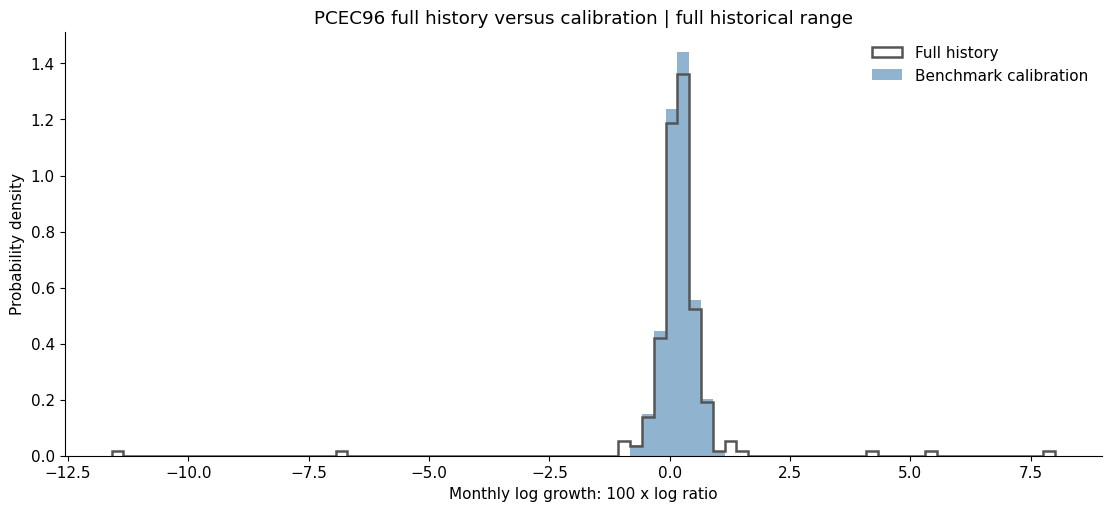

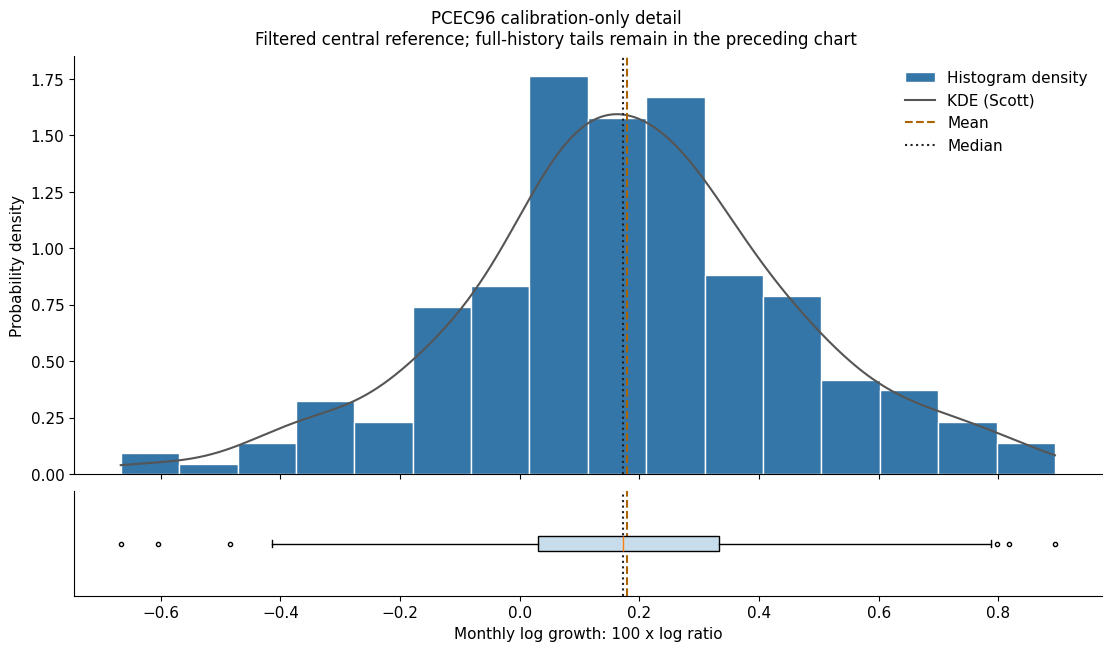

In [6]:
benchmark_stats=describe(benchmark_delta.delta_log_pct)
comparison=pd.DataFrame([{'sample':'Full historical',**full_stats},
 {'sample':'Eligible before filtering',**describe(calibration_history.delta_log_pct)},
 {'sample':'Benchmark calibration',**benchmark_stats}])
table(comparison)
fig,ax=plt.subplots(figsize=(11,5),layout='constrained')
edges=np.linspace(full_delta.delta_log_pct.min(),full_delta.delta_log_pct.max(),81)
ax.hist(full_delta.delta_log_pct,bins=edges,density=True,histtype='step',lw=1.8,color='#555555',label='Full history')
ax.hist(benchmark_delta.delta_log_pct,bins=edges,density=True,color='#3576A8',alpha=.55,label='Benchmark calibration')
ax.set(title='PCEC96 full history versus calibration | full historical range',xlabel='Monthly log growth: 100 x log ratio',ylabel='Probability density');ax.legend(frameon=False)
plt.show();plt.close(fig)
distribution_plot(benchmark_delta.delta_log_pct,'PCEC96 calibration-only detail\nFiltered central reference; full-history tails remain in the preceding chart')


## 8. Normalize every observation with the fixed benchmark

$$z_i=(\Delta_i-\mu_B)/s_B,\qquad percentile_i=100\#\{b\in B:b\leq\Delta_i\}/|B|.$$

Mean and sample standard deviation (ddof=1) use benchmark_delta only. Empirical percentiles use the same fixed calibration reference, with ties assigned the upper rank. Events below/above its range can receive 0/100; these are empirical positions, not tail-probability forecasts. Excluded events are still scored, with no z clipping.

In [7]:
benchmark_mean=benchmark_delta.delta_log_pct.mean();benchmark_std=benchmark_delta.delta_log_pct.std(ddof=1)
assert benchmark_std>0
reference=np.sort(benchmark_delta.delta_log_pct.to_numpy())
full_delta['benchmark_z']=(full_delta.delta_log_pct-benchmark_mean)/benchmark_std
full_delta['benchmark_percentile']=100*np.searchsorted(reference,full_delta.delta_log_pct,side='right')/len(reference)
assert full_delta[['benchmark_z','benchmark_percentile']].notna().all().all()


## 9. Directional benchmark states

Absolute z bands: [0,0.5) CENTRAL; [0.5,1) NORMAL; [1,2) ELEVATED; [2,3) EXTREME. At or above 3, use OUTLIER only when the robust exclusion rule also flags the observation. Otherwise retain EXTREME with a separate beyond_three_sigma flag. This prevents automatically treating every rare observation as an outlier. A robust flag below 3 remains visible but does not force an OUTLIER state.

Except CENTRAL, states retain the sign of z: above/below mean growth, not necessarily rising/falling consumption.

In [8]:
def classify(z,excluded):
 a=abs(z)
 if a<.5:return 'CENTRAL'
 label='NORMAL' if a<1 else 'ELEVATED' if a<2 else 'OUTLIER' if a>=3 and excluded else 'EXTREME'
 return label+(' POSITIVE' if z>0 else ' NEGATIVE')
assert classify(3,True)=='OUTLIER POSITIVE' and classify(-3,False)=='EXTREME NEGATIVE'
assert classify(.5,False)=='NORMAL POSITIVE' and classify(1,False)=='ELEVATED POSITIVE' and classify(2,False)=='EXTREME POSITIVE'
full_delta['benchmark_state']=[classify(z,flag) for z,flag in zip(full_delta.benchmark_z,full_delta.exclude_from_benchmark)]
full_delta['beyond_three_sigma']=full_delta.benchmark_z.abs().ge(3)
table(full_delta.groupby(['benchmark_state','exclude_from_benchmark'],as_index=False).size())


benchmark_state,exclude_from_benchmark,size
CENTRAL,False,103
ELEVATED NEGATIVE,False,26
ELEVATED POSITIVE,False,27
EXTREME NEGATIVE,False,7
EXTREME POSITIVE,False,6
NORMAL NEGATIVE,False,26
NORMAL POSITIVE,False,27
OUTLIER NEGATIVE,True,5
OUTLIER POSITIVE,True,7


## 10. Empirical benchmark ranges

All boundaries use benchmark_delta only. These nested intervals are separate from the sigma-based state bands; ties may make realized coverage differ from nominal coverage.

In [9]:
bq=benchmark_delta.delta_log_pct.quantile([.05,.10,.25,.50,.75,.90,.95])
table(pd.DataFrame([{'range':label,'lower_percentile':f'P{int(a*100)}','upper_percentile':f'P{int(b*100)}','lower_delta':bq.loc[a],'upper_delta':bq.loc[b]}
 for label,a,b in [('CENTRAL BENCHMARK RANGE',.25,.75),('NORMAL BENCHMARK RANGE',.10,.90),('OUTER BENCHMARK RANGE',.05,.95)]]))


range,lower_percentile,upper_percentile,lower_delta,upper_delta
CENTRAL BENCHMARK RANGE,P25,P75,0.0300609,0.333346
NORMAL BENCHMARK RANGE,P10,P90,-0.158594,0.521918
OUTER BENCHMARK RANGE,P5,P95,-0.306926,0.664263


## 11. Benchmark and preserved disruption observations

The central histogram uses calibration observations only. Cross markers show every robustly flagged full-history event on a separate rug; the x-axis includes the full history. Sigma lines and P5/P95 use only the calibration reference. The separate central-detail chart above supports readability without hiding events here.

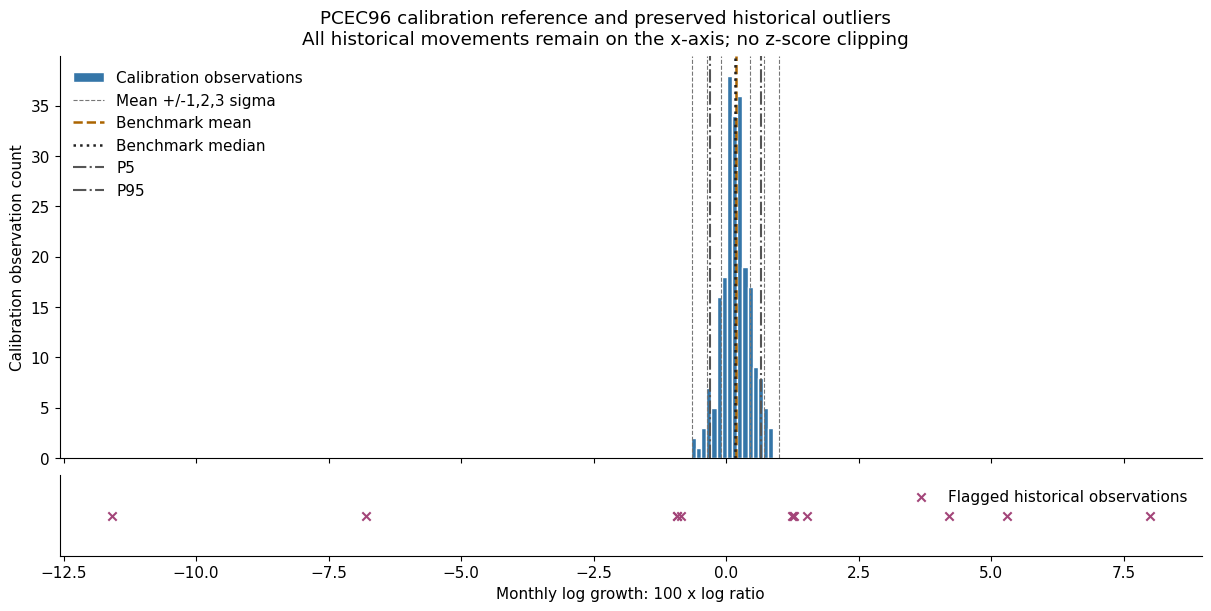

In [10]:
fig,(ax,rug)=plt.subplots(2,1,figsize=(12,6),sharex=True,gridspec_kw={'height_ratios':[5,1]},layout='constrained')
ax.hist(benchmark_delta.delta_log_pct,bins='auto',color='#3576A8',edgecolor='white',label='Calibration observations')
for k in [-3,-2,-1,1,2,3]:ax.axvline(benchmark_mean+k*benchmark_std,color='#777777',ls='--',lw=.8,label='Mean +/-1,2,3 sigma' if k==-3 else None)
ax.axvline(benchmark_mean,color='#AB6400',ls='--',lw=1.8,label='Benchmark mean')
ax.axvline(bq.loc[.50],color='#222222',ls=':',lw=1.8,label='Benchmark median')
for prob in [.05,.95]:ax.axvline(bq.loc[prob],color='#555555',ls='-.',label=f'P{int(prob*100)}')
events=full_delta.loc[full_delta.exclude_from_benchmark]
rug.scatter(events.delta_log_pct,np.zeros(len(events)),marker='x',color='#A34579',label='Flagged historical observations')
rug.set_yticks([]);rug.set_xlabel('Monthly log growth: 100 x log ratio');rug.legend(frameon=False,loc='upper right')
lo,hi=full_delta.delta_log_pct.min(),full_delta.delta_log_pct.max();ax.set_xlim(lo-.05*(hi-lo),hi+.05*(hi-lo))
ax.set_ylabel('Calibration observation count');ax.legend(frameon=False,loc='upper left')
fig.suptitle('PCEC96 calibration reference and preserved historical outliers\nAll historical movements remain on the x-axis; no z-score clipping')
plt.show();plt.close(fig)


## 12. Latest observation against the fixed historical reference

The latest month did not participate in threshold fitting or benchmark calibration. It is always reported, even if flagged. A statistical exclusion flag describes how it would be treated under the fixed rule, independently of the reporting holdout.

In [11]:
latest=full_delta.iloc[-1]
assert latest.date>CALIBRATION_END and not latest.used_for_calibration
latest_table=pd.DataFrame([{'date':latest.date,'level':latest.level,'previous_level':latest.previous_level,
 'delta_log_pct':latest.delta_log_pct,'calibration_cutoff':CALIBRATION_END,'benchmark_mean':benchmark_mean,
 'benchmark_std':benchmark_std,'benchmark_z':latest.benchmark_z,'benchmark_percentile':latest.benchmark_percentile,
 'benchmark_state':latest.benchmark_state,'exclude_from_benchmark':latest.exclude_from_benchmark}])
table(latest_table.T.reset_index().rename(columns={'index':'field',0:'value'}))


field,value
date,2026-07-01 00:00:00
level,"16,901.3"
previous_level,"16,900"
delta_log_pct,0.00769201
calibration_cutoff,2026-06-01 00:00:00
benchmark_mean,0.179163
benchmark_std,0.271737
benchmark_z,-0.631017
benchmark_percentile,22.1719
benchmark_state,NORMAL NEGATIVE


## 13. Robustness and time stability

ADF null: unit root; level specification uses constant + trend, delta uses constant, with AIC-selected lags. KPSS null: delta stationarity around a constant, with automatic lags. p < 0.05 rejects the relevant null. KPSS lookup-table bounds are reported. Tests use the full, consecutive calibration-eligible history, **not a compressed series with outlier dates removed**. They do not establish stable variance or rule out breaks.

Trailing windows span 60 calendar months. Full-history statistics require 60 values. The filtered comparison masks flagged months without collapsing dates, requires a full elapsed window and at least 48 retained values, and displays retained counts. Mean, sample std, median, and unscaled MAD are compared. These filtered diagnostics use full-calibration-sample flags retrospectively, not time-local event detection.

test,statistic,p_value,lags,null
ADF level: constant + trend,-2.36864,0.396417,11,Unit root
ADF delta: constant,-5.4251,2.99942e-06,10,Unit root
KPSS delta: constant,0.243091,0.1,19,Stationarity around constant


**KPSS limitation:** The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.


level_lag1_correlation,delta_lag1_correlation
0.9965,0.116647


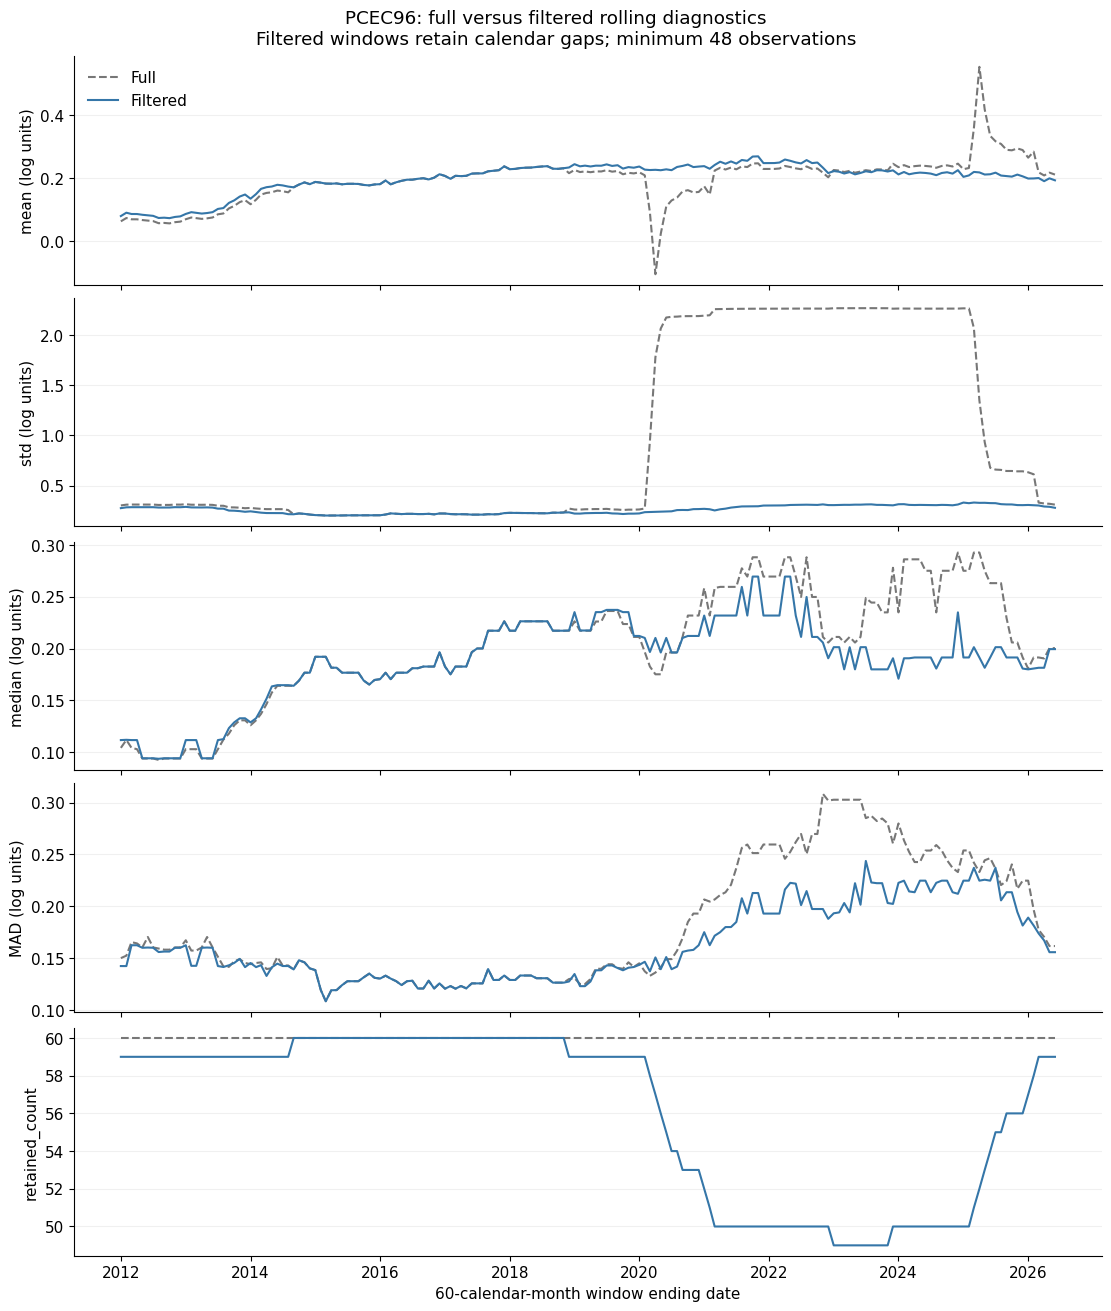

Filtered rolling std P90/P10: 1.4591955195202733 | rolling mean span / benchmark std: 0.7235758751533878


In [12]:
eligible=full_delta.loc[full_delta.calibration_eligible].copy()
a_level=adfuller(data.loc[data.date.le(CALIBRATION_END),'level'],regression='ct',autolag='AIC')
a_delta=adfuller(eligible.delta_log_pct,regression='c',autolag='AIC')
with warnings.catch_warnings(record=True) as caught:
 warnings.simplefilter('always');k_delta=kpss(eligible.delta_log_pct,regression='c',nlags='auto')
table(pd.DataFrame([{'test':'ADF level: constant + trend','statistic':a_level[0],'p_value':a_level[1],'lags':a_level[2],'null':'Unit root'},
 {'test':'ADF delta: constant','statistic':a_delta[0],'p_value':a_delta[1],'lags':a_delta[2],'null':'Unit root'},
 {'test':'KPSS delta: constant','statistic':k_delta[0],'p_value':k_delta[1],'lags':k_delta[2],'null':'Stationarity around constant'}]))
for w in caught:display(Markdown('**KPSS limitation:** '+str(w.message)))
table(pd.DataFrame([{'level_lag1_correlation':data.loc[data.date.le(CALIBRATION_END),'level'].autocorr(),
 'delta_lag1_correlation':eligible.delta_log_pct.autocorr()}]))
calendar=pd.date_range(eligible.date.min(),CALIBRATION_END,freq='MS')
series=eligible.set_index('date').delta_log_pct.reindex(calendar)
filtered=eligible.set_index('date').delta_log_pct.mask(eligible.set_index('date').exclude_from_benchmark).reindex(calendar)
rolling={}
for label,s,min_count in [('Full',series,60),('Filtered',filtered,48)]:
 r=s.rolling(60,min_periods=min_count)
 frame=pd.DataFrame({'mean':r.mean(),'std':r.std(ddof=1),'median':r.median(),
  'MAD':r.apply(lambda x:np.nanmedian(np.abs(x-np.nanmedian(x))),raw=True),'retained_count':s.rolling(60).count()})
 frame.iloc[:59,:]=np.nan
 rolling[label]=frame
fig,axes=plt.subplots(5,1,figsize=(11,13),sharex=True,layout='constrained')
for ax,metric in zip(axes,['mean','std','median','MAD','retained_count']):
 for label,color,style in [('Full','#777777','--'),('Filtered','#3576A8','-')]:
  ax.plot(rolling[label].index,rolling[label][metric],label=label,color=color,ls=style)
 ax.set_ylabel(metric if metric=='retained_count' else metric+' (log units)');ax.grid(axis='y',alpha=.18)
axes[0].legend(frameon=False);axes[-1].set_xlabel('60-calendar-month window ending date')
fig.suptitle('PCEC96: full versus filtered rolling diagnostics\nFiltered windows retain calendar gaps; minimum 48 observations')
plt.show();plt.close(fig)
filtered_roll=rolling['Filtered'].dropna()
rolling_std_ratio=filtered_roll['std'].quantile(.9)/filtered_roll['std'].quantile(.1)
rolling_mean_span=(filtered_roll['mean'].max()-filtered_roll['mean'].min())/benchmark_std
print('Filtered rolling std P90/P10:',rolling_std_ratio,'| rolling mean span / benchmark std:',rolling_mean_span)


## 14. Threshold sensitivity

Compare |modified_z| > 3.0, 3.5, and 4.0 using the **same fixed pre-holdout median/MAD**. Do not refit these robust inputs after exclusion. For an explicit descriptive stability screen, require max/min calibration std <= 1.25 and the range of calibration means <= 0.25 times the primary benchmark std. These chosen limits are not statistical tests. Skewness and kurtosis are shown for every threshold.

In [13]:
sensitivity_rows=[]
for threshold in [3.,3.5,4.]:
 keep=eligible.modified_z.abs().le(threshold);s=eligible.loc[keep,'delta_log_pct']
 sensitivity_rows.append({'threshold':threshold,'number_excluded':int((~keep).sum()),'observations':len(s),
 'benchmark_mean':s.mean(),'benchmark_std':s.std(ddof=1),'benchmark_skewness':s.skew(),'benchmark_kurtosis':s.kurt()})
sensitivity=pd.DataFrame(sensitivity_rows);table(sensitivity)
std_sensitivity=sensitivity.benchmark_std.max()/sensitivity.benchmark_std.min()
mean_sensitivity=(sensitivity.benchmark_mean.max()-sensitivity.benchmark_mean.min())/benchmark_std
threshold_stable=bool(std_sensitivity<=1.25 and mean_sensitivity<=.25)
display(Markdown(f'**Threshold screen: {"stable" if threshold_stable else "threshold-sensitive"}.** '
 f'Max/min std = {std_sensitivity:.3f}; mean range / primary std = {mean_sensitivity:.3f}. '
 'This screen describes sensitivity to the threshold; it does not prove model validity.'))


threshold,number_excluded,observations,benchmark_mean,benchmark_std,benchmark_skewness,benchmark_kurtosis
3,14,219,0.186606,0.261456,0.0809025,0.13148
3.5,12,221,0.179163,0.271737,-0.101116,0.427681
4,12,221,0.179163,0.271737,-0.101116,0.427681


**Threshold screen: stable.** Max/min std = 1.039; mean range / primary std = 0.027. This screen describes sensitivity to the threshold; it does not prove model validity.

## 15. Suitability rubric and audit summary

The label is computed, not preselected. **NOT SUITABLE** if fewer than 120 calibration observations, invalid/zero benchmark std, or more than 20% of eligible history is excluded. Otherwise **REGIME-SENSITIVE** if delta ADF fails to reject a unit root, KPSS rejects stationarity, threshold stability fails, filtered rolling std P90/P10 exceeds 3, or filtered rolling mean spans more than 2 benchmark standard deviations.

If those screens pass, **PASS WITH OUTLIER-ROBUST CALIBRATION** requires 0-15% exclusions (strictly positive), at least a 20% reduction in std versus unfiltered eligible history, lower absolute excess kurtosis, and calibration |skewness| <= 1 and excess kurtosis <= 3. **PASS** requires no exclusions and those shape limits. Remaining cases receive REGIME-SENSITIVE for further work. Thresholds are transparent exploratory choices, not formal proof of separate regimes or normality. Improved marginal shape after filtering alone is insufficient.

In [14]:
excluded_count=int(eligible.exclude_from_benchmark.sum());excluded_share=excluded_count/len(eligible)
base_stats=describe(eligible.delta_log_pct)
std_reduction=1-benchmark_std/base_stats['std']
shape_ok=abs(benchmark_stats['skewness'])<=1 and benchmark_stats['excess_kurtosis']<=3
material_improvement=std_reduction>=.20 and abs(benchmark_stats['excess_kurtosis'])<abs(base_stats['excess_kurtosis'])
flags=[]
if a_delta[1]>=.05:flags.append('delta ADF does not reject a unit root')
if k_delta[1]<.05:flags.append('KPSS rejects constant-mean stationarity')
if not threshold_stable:flags.append('threshold-sensitive calibration')
if rolling_std_ratio>3:flags.append('filtered rolling volatility ratio exceeds 3')
if rolling_mean_span>2:flags.append('filtered rolling mean span exceeds 2 benchmark sigma')
if len(benchmark_delta)<120 or not np.isfinite(benchmark_std) or benchmark_std<=0 or excluded_share>.20:
 label='NOT SUITABLE'
elif flags:label='REGIME-SENSITIVE'
elif 0<excluded_share<=.15 and material_improvement and shape_ok:label='PASS WITH OUTLIER-ROBUST CALIBRATION'
elif excluded_count==0 and shape_ok:label='PASS'
else:
 label='REGIME-SENSITIVE';flags.append('exclusion fraction, shape or improvement screen not satisfied')
covid=eligible.loc[eligible.date.dt.year.eq(2020)]
summary=(f'### Audit verdict: {label}\n\n'
 '**Series:** PCEC96 - Real Personal Consumption Expenditures.  \n'
 '**Transformation:** 100 times one-month log difference.  \n'
 '**Historical observations:** all preserved.  \n'
 '**Calibration:** exclude statistically flagged disruption observations using median/MAD modified z, absolute value > 3.5.  \n'
 '**Normalization:** mean/std and empirical percentiles from retained calibration observations only.  \n'
 '**Historical outlier scoring:** every event remains visible and receives benchmark z, percentile, and state.  \n'
 '**Tail treatment:** retain, flag, exclude from calibration; never winsorize or clip.  \n'
 '**Economic role:** how unusual current real-consumption growth is relative to ordinary historical monthly consumption behavior.\n\n'
 f'**Evidence:** {excluded_count}/{len(eligible)} eligible months excluded ({100*excluded_share:.2f}%); '
 f'calibration std changes from {base_stats["std"]:.4f} to {benchmark_std:.4f} ({100*std_reduction:.1f}% reduction); '
 f'excess kurtosis changes from {base_stats["excess_kurtosis"]:.2f} to {benchmark_stats["excess_kurtosis"]:.2f}. '
 f'Threshold stability screen: {threshold_stable}. Filtered rolling std ratio {rolling_std_ratio:.2f}; '
 f'rolling mean span {rolling_mean_span:.2f} benchmark sigma. '
 f'Additional flags: {"; ".join(flags) if flags else "none under the stated rubric"}.\n\n'
 f'The rule flags {int(covid.exclude_from_benchmark.sum())} of {len(covid)} eligible observations dated in 2020. '
 'COVID-era observations are preserved as real historical events, not removed because they are inconvenient. '
 'They leave calibration only if the statistical rule flags them; dates never determine exclusions. '
 'The rule may also flag other periods, as the complete event table shows.\n\n'
 f'Latest month {latest.date:%Y-%m-%d}: log growth {latest.delta_log_pct:.4f}, benchmark z {latest.benchmark_z:.3f}, '
 f'percentile {latest.benchmark_percentile:.2f}, state **{latest.benchmark_state}**. '
 'It is scored against the frozen pre-latest reference regardless of its exclusion flag. '
 'This single snapshot audit does not validate an operational benchmark, causal attribution, or real-time forecasting performance.')
display(Markdown(summary))


### Audit verdict: PASS WITH OUTLIER-ROBUST CALIBRATION

**Series:** PCEC96 - Real Personal Consumption Expenditures.  
**Transformation:** 100 times one-month log difference.  
**Historical observations:** all preserved.  
**Calibration:** exclude statistically flagged disruption observations using median/MAD modified z, absolute value > 3.5.  
**Normalization:** mean/std and empirical percentiles from retained calibration observations only.  
**Historical outlier scoring:** every event remains visible and receives benchmark z, percentile, and state.  
**Tail treatment:** retain, flag, exclude from calibration; never winsorize or clip.  
**Economic role:** how unusual current real-consumption growth is relative to ordinary historical monthly consumption behavior.

**Evidence:** 12/233 eligible months excluded (5.15%); calibration std changes from 1.1672 to 0.2717 (76.7% reduction); excess kurtosis changes from 59.60 to 0.43. Threshold stability screen: True. Filtered rolling std ratio 1.46; rolling mean span 0.72 benchmark sigma. Additional flags: none under the stated rubric.

The rule flags 6 of 12 eligible observations dated in 2020. COVID-era observations are preserved as real historical events, not removed because they are inconvenient. They leave calibration only if the statistical rule flags them; dates never determine exclusions. The rule may also flag other periods, as the complete event table shows.

Latest month 2026-07-01: log growth 0.0077, benchmark z -0.631, percentile 22.17, state **NORMAL NEGATIVE**. It is scored against the frozen pre-latest reference regardless of its exclusion flag. This single snapshot audit does not validate an operational benchmark, causal attribution, or real-time forecasting performance.

In [15]:
assert len(full_delta)==len(raw)-1
assert len(benchmark_delta)+excluded_count==len(eligible)
assert np.isfinite(full_delta.benchmark_z).all()
assert all(digest(ROOT/path)==h for path,h in hashes.items())
assert not full_delta.loc[full_delta.date.gt(CALIBRATION_END),'used_for_calibration'].any()
print('Verified: all cleaned CSVs and both reference notebooks unchanged; full history retained and scored.')
print('Python',platform.python_version(),'pandas',pd.__version__,'NumPy',np.__version__,'SciPy',scipy.__version__,'statsmodels',statsmodels.__version__)
table(pd.DataFrame([{'source':path,'sha256':h} for path,h in hashes.items() if 'PCEC96' in path or path.endswith('.ipynb')]))


Verified: all cleaned CSVs and both reference notebooks unchanged; full history retained and scored.
Python 3.14.2 pandas 3.0.2 NumPy 2.4.4 SciPy 1.17.1 statsmodels 0.14.6


source,sha256
data\cleaned\PCEC96.csv,dd970db5c76664700a7acce362b59b726c9b9764ed32c0d90e1a40815ce74d9a
notebook\deltaAnalysis\analysis.ipynb,8692512bbe246ff6fb29b64c6c4011999b9ff4f10173531f1d2a6c84f4dfdf87
notebook\deltaAnalysis\audit-PPIACO.ipynb,d9cb486159943906b84bbb6b268206f3c39f560bdd36e54f9c31925cec7d72d1
